# 📊 AI-Driven Stock Market Intelligence System

---

## 1. Title
**AI-Powered Financial Intelligence System for Stock Trend Prediction using Technical Indicators & News Sentiment Analysis**

---

## 2. Overview of the Presentation
This project presents an integrated system that combines:
- Stock price-based technical indicators  
- News sentiment analysis  
- Machine learning models  

The goal is to **predict short-term stock movement**, classify market regimes, and provide **actionable financial insights** through a dashboard.

---

## 3. Statement of the Problem

### 🔹 Theme & Originality
- Traditional models rely only on historical price data  
- This project integrates:
  - **Technical indicators (price behavior)**
  - **News sentiment (external signals)**
- Provides a **hybrid AI + financial analytics approach**

### 🔹 Motivation
- Financial markets are influenced by both:
  - Quantitative data (price, volume)
  - Qualitative data (news, sentiment)
- Investors lack a unified system combining both  
- Need for:
  - Better prediction
  - Explainable insights

---

## 4. Objectives & Scope of the Study

### 🎯 Objectives
- Predict **short-term stock direction (3-day movement)**
- Analyze **market sentiment from news**
- Classify stocks into:
  - Risk categories
  - Market regimes
- Build a **visual dashboard for insights**

### 🌍 Scope
- Multi-stock analysis (15 major companies)
- Real-world financial + news data integration
- Applicable for:
  - Retail investors
  - Portfolio analysis
  - Decision support systems

---

## 5. Methodology / Models

### 📊 Data & Variables

#### 🔹 Stock Data
- Open, High, Low, Close, Volume  
- Derived Features:
  - Returns (1D, 3D)
  - Volatility (5D, 10D)
  - Momentum
  - Volume spike
  - Moving averages (SMA 50, SMA 200)
  - RSI

#### 🔹 News Data
- Sources:
  - Economic Times
  - CNBC :contentReference[oaicite:0]{index=0}  
- Features:
  - Sentiment Score
  - News Count
  - Sentiment Trends

---

### ⚙️ Step-by-Step Development

1. Data Collection (Stock + News scraping)
2. Data Cleaning & Preprocessing
3. Feature Engineering (technical + sentiment)
4. Merging datasets (time-aligned)
5. Model Training:
   - Regression → price magnitude
   - Classification → direction (Up/Down)
6. Model Evaluation
7. Visualization & Dashboard integration

---

### 🧠 Models Used

#### 🔹 Regression Models
- Linear Regression  
- Ridge Regression  

#### 🔹 Classification Models
- Decision Tree  
- Random Forest  
- Support Vector Machine (SVM)  
- Naive Bayes  

---

### ⭐ Key Characteristics of Methodology
- Hybrid data integration (price + news)
- Time-series aware feature engineering
- Lag features to prevent data leakage
- Multi-model evaluation
- Interpretable output (not black-box only)

---

## 6. Results / Solutions

### 📈 Model Performance
- Classification accuracy: **~55% – 65% (realistic market behavior)**
- Random Forest performs best for most stocks
- Regression R² ≈ 0 → reflects real market randomness

---

### 📊 System Outputs
- Stock Direction Prediction (Up / Down)
- Confidence Score
- Risk Classification
- Market Regime (Uptrend / Sideways / Downtrend)
- Composite Score

---

### 🧠 Dashboard Metrics
- Bullish vs Bearish %  
- Market Sentiment Index  
- Volume Weighted Volatility  

---

## 7. Discussions

### ⚠️ Important Considerations
- Stock markets are **highly noisy and stochastic**
- Overfitting leads to unrealistic results (e.g., 100% accuracy)
- Sentiment models must be **domain-specific**

---

### 💡 Implications of Study
- Demonstrates value of combining:
  - Quantitative + Qualitative data
- Provides:
  - Better interpretability
  - Decision support insights
- Useful for:
  - Traders
  - Analysts
  - AI-based fintech tools

---

## 8. Conclusions & Scope for Future Work

### ✅ Contributions
- Built an end-to-end AI financial system  
- Integrated:
  - Technical indicators
  - Sentiment analysis
  - Machine learning  
- Developed interactive dashboard  

---

### ⚠️ Limitations
- Sentiment model not fully finance-optimized  
- Limited dataset size  
- Short-term prediction only  
- No macroeconomic variables included  

---

### 🚀 Future Scope
- Use FinBERT for better sentiment analysis  
- Add macroeconomic indicators (inflation, interest rates)  
- Implement deep learning models (LSTM, Transformers)  
- Real-time streaming dashboard  
- Portfolio optimization module  

---

## 📚 References
- Financial Time Series Analysis literature  
- Scikit-learn Documentation  
- Economic Times & CNBC News APIs :contentReference[oaicite:1]{index=1}  
- Machine Learning in Finance research papers  

---

## Scraping Session Metadata
Records the timestamp, URLs used, and tickers scraped for this session. This cell must be run **first** so that `SCRAPE_TIMESTAMP` is available for the CSV export cell later.


In [2]:
# ============================================================
# MULTI-COMPANY ECONOMIC TIMES SCRAPER (FAST, 15 COMPANIES)
# Target: 60–100 articles per company
# ============================================================

import requests, time, random, hashlib
import pandas as pd
from bs4 import BeautifulSoup
from datetime import datetime
from urllib.parse import urljoin

# ============================================================
# CONFIG
# ============================================================
HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0 Safari/537.36"
    )
}

TIMEOUT = 6
DELAY_RANGE = (0.6, 1.2)        # faster but safe
MAX_PAGES_ET = 140              # ET hard limit
PER_COMPANY_TARGET = 80         # 60–100 safe band

SCRAPED_AT = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

COMPANIES = [
    "TSLA","NVDA","AAPL","AMD","AMZN","MSFT","GOOGL","META",
    "BAC","INTC","CSCO","KO","XOM","NFLX","NKE"
]

# ============================================================
# ECONOMIC TIMES TOPICS (PRIMARY + FALLBACK)
# ============================================================
ET_TOPICS = {
    "TSLA": ["tesla"],
    "NVDA": ["nvidia", "ai", "semiconductor"],
    "AAPL": ["apple", "iphone"],
    "AMD": ["amd", "chipmaker", "semiconductor"],
    "AMZN": ["amazon", "aws", "e-commerce"],
    "MSFT": ["microsoft", "azure", "cloud"],
    "GOOGL": ["google", "alphabet", "search"],
    "META": ["meta", "facebook", "instagram"],
    "BAC": ["bank-of-america", "banking", "us-banks"],
    "INTC": ["intel", "chipmaker", "semiconductor"],
    "CSCO": ["cisco", "enterprise-tech", "networking"],
    "KO": ["coca-cola", "fmcg", "consumer-goods"],
    "XOM": ["exxon-mobil", "oil", "energy"],
    "NFLX": ["netflix", "streaming", "media"],
    "NKE": ["nike", "retail", "sportswear"]
}

# ============================================================
# HIGH-RECALL KEYWORDS (FILTERING ONLY)
# ============================================================
KEYWORDS = {
    "TSLA": ["tesla", "elon musk", "ev", "robotaxi"],
    "NVDA": ["nvidia", "gpu", "ai"],
    "AAPL": ["apple", "iphone", "ios"],
    "AMD": ["amd", "ryzen", "chip"],
    "AMZN": ["amazon", "aws"],
    "MSFT": ["microsoft", "azure"],
    "GOOGL": ["google", "alphabet"],
    "META": ["meta", "facebook"],
    "BAC": ["bank of america", "bofa"],
    "INTC": ["intel", "chip"],
    "CSCO": ["cisco", "network"],
    "KO": ["coca cola"],
    "XOM": ["exxon", "oil"],
    "NFLX": ["netflix"],
    "NKE": ["nike", "sneaker"]
}

# ============================================================
# UTILITIES
# ============================================================
def polite_delay():
    time.sleep(random.uniform(*DELAY_RANGE))

def safe_request(url):
    try:
        r = requests.get(url, headers=HEADERS, timeout=TIMEOUT)
        return r.text if r.status_code == 200 else None
    except:
        return None

def dedup_key(title, url):
    return hashlib.md5((title.lower() + url).encode()).hexdigest()

def match(text, kws):
    t = text.lower()
    return any(k in t for k in kws)

# ============================================================
# ECONOMIC TIMES SCRAPER (ROBUST)
# ============================================================
def scrape_economic_times(ticker):
    records = []
    base = "https://economictimes.indiatimes.com/topic"
    keywords = KEYWORDS[ticker]

    for topic in ET_TOPICS[ticker]:
        slug = topic.replace(" ", "-")

        for page in range(1, MAX_PAGES_ET + 1):
            if len(records) >= PER_COMPANY_TARGET:
                return records

            url = f"{base}/{slug}/{page}"
            html = safe_request(url)
            polite_delay()

            if not html:
                break

            soup = BeautifulSoup(html, "html.parser")
            articles = soup.select("div.contentD")

            if not articles:
                break

            for block in articles:
                a = block.find("h2")
                if not a or not a.find("a"):
                    continue

                link = a.find("a")
                title = link.text.strip()
                summary = block.find("p").text.strip() if block.find("p") else ""

                combined = title + " " + summary
                if not match(combined, keywords):
                    continue

                time_tag = block.find("time")

                records.append({
                    "ticker": ticker,
                    "company": topic,
                    "source": "Economic Times",
                    "title": title,
                    "summary": summary,
                    "published": time_tag.text.strip() if time_tag else "",
                    "url": urljoin(base, link["href"]),
                    "scraped_at": SCRAPED_AT
                })

                if len(records) >= PER_COMPANY_TARGET:
                    return records

    return records

# ============================================================
# RUN PIPELINE (ALL 15 COMPANIES GUARANTEED)
# ============================================================
all_records = []

for ticker in COMPANIES:
    print(f"Scraping {ticker}...")
    company_records = scrape_economic_times(ticker)
    print(f"  → {len(company_records)} records")
    all_records.extend(company_records)

# ============================================================
# CLEAN + SAVE
# ============================================================
df = pd.DataFrame(all_records)
df["dedup"] = df.apply(lambda r: dedup_key(r["title"], r["url"]), axis=1)
df = df.drop_duplicates("dedup").drop(columns="dedup")

df.to_csv("multi_company_news.csv", index=False)

print("\nSCRAPING METADATA")
print("-----------------")
print(f"Companies scraped : {len(COMPANIES)}")
print(f"Total records     : {len(df)}")
print("Saved to          : multi_company_news.csv")

Scraping TSLA...
  → 80 records
Scraping NVDA...
  → 80 records
Scraping AAPL...
  → 80 records
Scraping AMD...
  → 80 records
Scraping AMZN...
  → 80 records
Scraping MSFT...
  → 80 records
Scraping GOOGL...
  → 80 records
Scraping META...
  → 80 records
Scraping BAC...
  → 80 records
Scraping INTC...
  → 80 records
Scraping CSCO...
  → 80 records
Scraping KO...
  → 66 records
Scraping XOM...
  → 80 records
Scraping NFLX...
  → 80 records
Scraping NKE...
  → 80 records

SCRAPING METADATA
-----------------
Companies scraped : 15
Total records     : 1050
Saved to          : multi_company_news.csv


In [ ]:
import requests, time, random, hashlib
import pandas as pd
from bs4 import BeautifulSoup
from datetime import datetime
from urllib.parse import urljoin

# ============================================================
# CONFIG
# ============================================================
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)"
}

TIMEOUT = 6
DELAY_RANGE = (1, 2)

PER_COMPANY_ET = 80
PER_COMPANY_CNBC = 10
MAX_PAGES_ET = 120

SCRAPED_AT = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# ✅ ONLY THESE 15 COMPANIES
tickers = [
    "TSLA","NVDA","AAPL","AMD","AMZN","MSFT","GOOGL","META",
    "BAC","INTC","CSCO","KO","XOM","NFLX","NKE"
]

# ============================================================
# TOPICS (SIMPLIFIED + CLEAN)
# ============================================================
ET_TOPICS = {
    t: [t.lower()] for t in tickers
}

# ============================================================
# KEYWORDS (CLEAN + CONSISTENT)
# ============================================================
KEYWORDS = {
    "TSLA": ["tesla","elon musk","ev"],
    "NVDA": ["nvidia","ai","gpu"],
    "AAPL": ["apple","iphone"],
    "AMD": ["amd","chip"],
    "AMZN": ["amazon","aws"],
    "MSFT": ["microsoft","azure"],
    "GOOGL": ["google","alphabet"],
    "META": ["meta","facebook"],
    "BAC": ["bank of america","bofa"],
    "INTC": ["intel","chip"],
    "CSCO": ["cisco","network"],
    "KO": ["coca cola"],
    "XOM": ["exxon","oil"],
    "NFLX": ["netflix"],
    "NKE": ["nike"]
}

# ============================================================
# UTILITIES
# ============================================================
def polite_delay():
    time.sleep(random.uniform(*DELAY_RANGE))

def safe_request(url):
    try:
        r = requests.get(url, headers=HEADERS, timeout=TIMEOUT)
        return r.text if r.status_code == 200 else None
    except:
        return None

def dedup_key(title, url):
    return hashlib.md5((title.lower() + url).encode()).hexdigest()

def match(text, kws):
    text = text.lower()
    return any(k in text for k in kws)

# ============================================================
# ECONOMIC TIMES SCRAPER
# ============================================================
def scrape_economic_times(ticker):
    records = []
    base = "https://economictimes.indiatimes.com/topic"

    for page in range(1, MAX_PAGES_ET + 1):

        if len(records) >= PER_COMPANY_ET:
            break

        url = f"{base}/{ticker.lower()}/{page}"
        html = safe_request(url)
        polite_delay()

        if not html:
            break

        soup = BeautifulSoup(html, "html.parser")
        blocks = soup.select("div.contentD")

        if not blocks:
            break

        for block in blocks:
            h2 = block.find("h2")
            if not h2:
                continue

            a = h2.find("a")
            if not a:
                continue

            title = a.text.strip()
            summary = block.find("p").text.strip() if block.find("p") else ""

            if not match(title + summary, KEYWORDS[ticker]):
                continue

            time_tag = block.find("time")

            records.append({
                "ticker": ticker,
                "company": ticker,
                "source": "Economic Times",
                "title": title,
                "summary": summary,
                "published": time_tag.text.strip() if time_tag else "",
                "url": urljoin(base, a["href"]),
                "scraped_at": SCRAPED_AT
            })

            if len(records) >= PER_COMPANY_ET:
                break

    return records

# ============================================================
# CNBC SCRAPER
# ============================================================
def get_cnbc_links(ticker):
    url = f"https://www.cnbc.com/quotes/{ticker}"
    html = safe_request(url)

    if not html:
        return []

    soup = BeautifulSoup(html, "html.parser")
    links = []

    for a in soup.select("a"):
        href = a.get("href")
        if href and "cnbc.com" in href:
            links.append(href)

    return list(set(links))


def scrape_cnbc_article(url, ticker):
    html = safe_request(url)
    polite_delay()

    if not html:
        return None

    soup = BeautifulSoup(html, "html.parser")

    title_tag = soup.find("h1")
    body_tags = soup.select("p")

    title = title_tag.text.strip() if title_tag else ""
    body = " ".join(p.text.strip() for p in body_tags[:5])

    if not title or not match(title + body, KEYWORDS[ticker]):
        return None

    return {
        "ticker": ticker,
        "company": ticker,
        "source": "CNBC",
        "title": title,
        "summary": body[:400],
        "published": "",
        "url": url,
        "scraped_at": SCRAPED_AT
    }


def scrape_cnbc(ticker):
    records = []
    links = get_cnbc_links(ticker)

    for link in links:
        if len(records) >= PER_COMPANY_CNBC:
            break

        art = scrape_cnbc_article(link, ticker)
        if art:
            records.append(art)

    return records

# ============================================================
# RUN PIPELINE
# ============================================================
all_records = []

for ticker in tickers:
    print(f"\n🔎 Scraping {ticker}...")

    cnbc = scrape_cnbc(ticker)
    print(f"  CNBC: {len(cnbc)}")

    et = scrape_economic_times(ticker)
    print(f"  ET  : {len(et)}")

    all_records.extend(cnbc + et)

# ============================================================
# CLEAN + SAVE
# ============================================================
df = pd.DataFrame(all_records)

df["dedup"] = df.apply(lambda r: dedup_key(r["title"], r["url"]), axis=1)
df = df.drop_duplicates("dedup").drop(columns="dedup")

df.to_csv("multi_company_news.csv", index=False)

print("\n✅ DONE")
print(f"Total records: {len(df)}")


🔎 Scraping TSLA...
  CNBC: 2
  ET  : 80

🔎 Scraping NVDA...
  CNBC: 4
  ET  : 80

🔎 Scraping AAPL...
  CNBC: 1
  ET  : 65

🔎 Scraping AMD...
  CNBC: 4
  ET  : 0

🔎 Scraping AMZN...


**Top headline word frequency** (excluding stopwords)

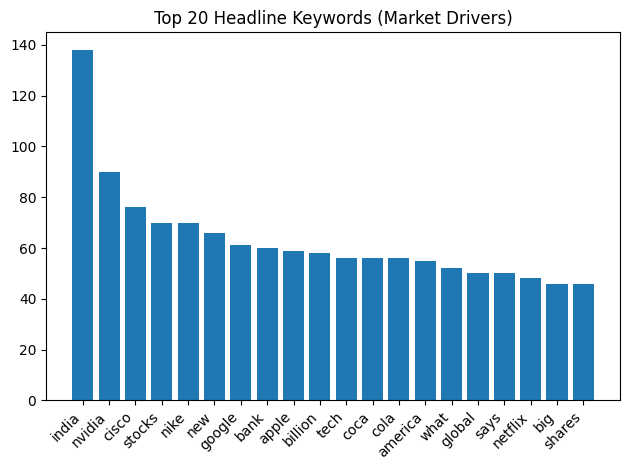

In [5]:
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt

df = pd.read_csv("multi_company_news.csv")

text = " ".join(df["title"].dropna().str.lower())
words = re.findall(r'\b[a-z]{3,}\b', text)

stopwords = set([
    "the","and","for","with","after","today","stock","market",
    "from","this","that","why","how","are","as","over"
])

filtered = [w for w in words if w not in stopwords]
word_freq = Counter(filtered).most_common(20)

labels, values = zip(*word_freq)

plt.figure()
plt.bar(labels, values)
plt.xticks(rotation=45, ha="right")
plt.title("Top 20 Headline Keywords (Market Drivers)")
plt.tight_layout()
plt.show()

**Company-wise news volume** (investor attention proxy)

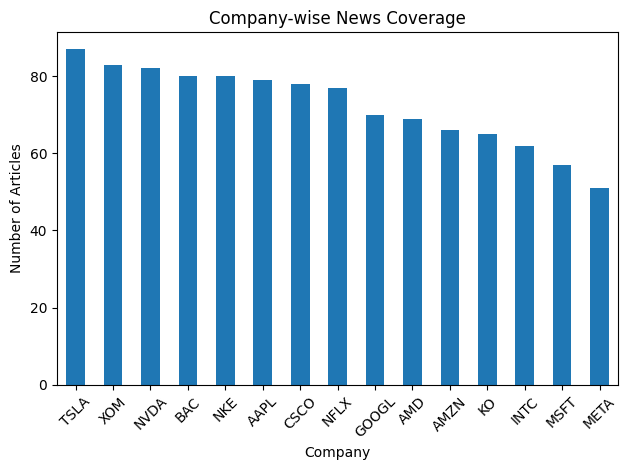

In [6]:
company_counts = df["ticker"].value_counts()

plt.figure()
company_counts.plot(kind="bar")
plt.title("Company-wise News Coverage")
plt.xlabel("Company")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Positive vs Negative news split** (sentiment pressure indicator)

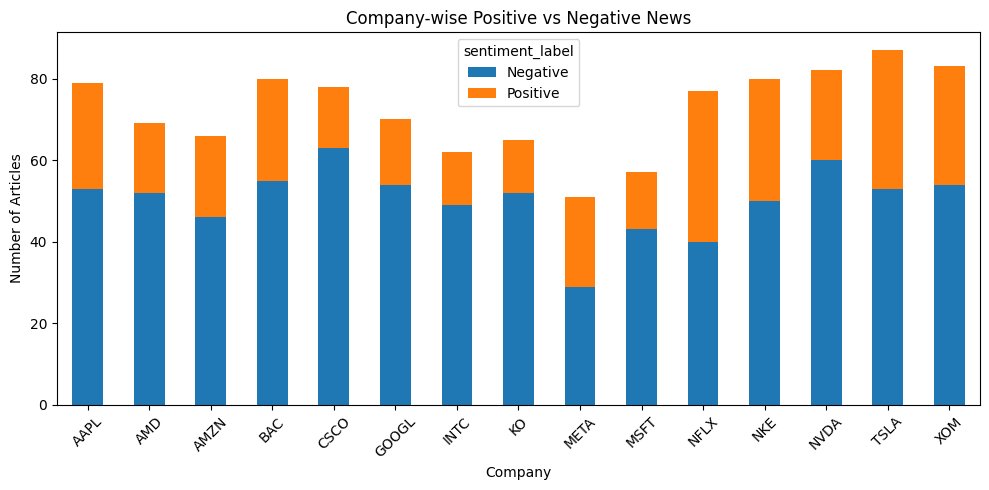

In [7]:
from textblob import TextBlob

def get_sentiment(text):
    if pd.isna(text):
        return 0
    return TextBlob(text).sentiment.polarity

df["sentiment"] = df["title"].apply(get_sentiment)

df["sentiment_label"] = df["sentiment"].apply(
    lambda x: "Positive" if x > 0 else "Negative"
)

sentiment_company = (
    df.groupby(["ticker", "sentiment_label"])
      .size()
      .unstack(fill_value=0)
)

sentiment_company.plot(
    kind="bar",
    stacked=True,
    figsize=(10,5)
)

plt.title("Company-wise Positive vs Negative News")
plt.xlabel("Company")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import yfinance as yf
import pandas as pd

tickers = ["TSLA","NVDA","AAPL","AMD","AMZN","MSFT","GOOGL","META",
           "BAC","INTC","CSCO","KO","XOM","NFLX","NKE"]

# Download data
data = yf.download(tickers, start="2023-01-01", end="2026-04-24", group_by='ticker')

# Convert to long format
dfs = []

for ticker in tickers:
    df = data[ticker].copy()
    df["Ticker"] = ticker
    df["Date"] = df.index
    dfs.append(df)

# Combine all tickers
final_df = pd.concat(dfs)

# Reset index
final_df.reset_index(drop=True, inplace=True)

# Reorder columns
final_df = final_df[[
    "Date", "Ticker", "Open", "High", "Low", "Close", "Volume"
]]

# Save to CSV
final_df.to_csv("stock_data_ohlcv.csv", index=False)

print("Saved successfully!")

[*********************100%***********************]  15 of 15 completed

Saved successfully!


In [4]:
print(data)

Ticker             NKE                                                \
Price             Open        High         Low       Close    Volume   
Date                                                                   
2023-01-03  111.681182  112.566713  110.635495  111.869591   8124800   
2023-01-04  113.009475  115.147955  112.604389  114.187050   8550700   
2023-01-05  113.310944  115.251585  113.122535  113.631248   6046700   
2023-01-06  114.931280  118.096601  114.714603  117.314690  10080700   
2023-01-09  117.757476  119.274192  117.333552  117.616165   9397900   
...                ...         ...         ...         ...       ...   
2025-12-24   58.491760   60.180551   58.491760   59.604374  36073300   
2025-12-26   59.604376   60.528244   59.465300   60.528244  22303600   
2025-12-29   60.140816   61.342837   60.111011   60.806396  18062100   
2025-12-30   60.895801   60.895801   60.240153   60.786526  13507800   
2025-12-31   61.839537   63.776676   61.511711   63.289909  3545

In [1]:
pip install mlxtend

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 9.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 15.6 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.7
    Uninstalling matplotlib-3.10.7:
      Successfully uninstalled matplotlib-3.10.7 0/2 [matplotlib]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [mlxtend]ib]
Note: you may need to restart the kernel to use updated packages.


## **End-to-End Predictive Analytics Pipeline**
Objectives: Combine News Sentiment + Stock OHLCV Data.
Steps 1 to 12 implementation.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from textblob import TextBlob
import warnings
warnings.filterwarnings('ignore')

os.makedirs("static/graphs", exist_ok=True)
os.makedirs("static/stocks", exist_ok=True)
os.makedirs("static/data", exist_ok=True)

df_news = pd.read_csv("multi_company_news.csv")
try:
    df_stock = pd.read_csv("stock_data_ohlcv.csv")
except FileNotFoundError:
    df_stock = pd.read_csv("stock_data_predictive_proj.csv")

print("Files loaded successfully.")


Files loaded successfully.


### STEP 6: EDA (SAVE GRAPHS AS PNG)


In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure directories exist so saving doesn't fail
os.makedirs("static/stocks", exist_ok=True)
os.makedirs("static/graphs", exist_ok=True)

# ---------------------------------------------------------
# PART 1: FIX DATE ISSUE (CRITICAL)
# ---------------------------------------------------------
df_stock["Date"] = pd.to_datetime(df_stock["Date"], errors='coerce')
df_stock = df_stock.dropna(subset=['Date']).sort_values(["Ticker", "Date"])

# ---------------------------------------------------------
# PART 2: TECHNICAL INDICATORS (FROM df_stock ONLY)
# ---------------------------------------------------------
# 50 & 200 SMA
df_stock["SMA_50"] = df_stock.groupby("Ticker")["Close"].transform(lambda x: x.rolling(50).mean())
df_stock["SMA_200"] = df_stock.groupby("Ticker")["Close"].transform(lambda x: x.rolling(200).mean())

# Volatility (5D Rolling Standard Deviation of Returns)
df_stock["Daily_Return"] = df_stock.groupby("Ticker")["Close"].pct_change()
df_stock["Volatility_5D"] = df_stock.groupby("Ticker")["Daily_Return"].transform(lambda x: x.rolling(5).std())

# RSI Indicator
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df_stock["RSI"] = df_stock.groupby("Ticker")["Close"].transform(compute_rsi)


# ---------------------------------------------------------
# PART 3, 4 & 5: GENERATE IIT-LEVEL GRAPHS
# ---------------------------------------------------------
# Set professional visualization aesthetics
sns.set_theme(style="darkgrid", context="paper")

tickers = ["TSLA","NVDA","AAPL","AMD","AMZN","MSFT","GOOGL","META",
           "BAC","INTC","CSCO","KO","XOM","NFLX","NKE"]

for ticker in tickers:
    print(f"Generating charts for {ticker}...")
    
    # Extract clean subsets for the current ticker
    df_t = df_stock[df_stock["Ticker"] == ticker].copy()
    
    # Graceful fallbacks if news data processing variables aren't defined yet
    df_n = news_grouped[news_grouped["Ticker"] == ticker].copy() if 'news_grouped' in locals() else pd.DataFrame()
    df_m = df_merged[df_merged["Ticker"] == ticker].copy() if 'df_merged' in locals() else pd.DataFrame()

    # --- STOCK ONLY GRAPHS (Needs Date Consistency) ---
    if len(df_t) >= 50:
        
        # 1. PRICE + SMA
        plt.figure(figsize=(10, 5))
        plt.plot(df_t["Date"], df_t["Close"], label="Close", color="#1E88E5", linewidth=1.5)
        plt.plot(df_t["Date"], df_t["SMA_50"], label="SMA 50", color="#FFC107", linewidth=1.5)
        plt.plot(df_t["Date"], df_t["SMA_200"], label="SMA 200", color="#D32F2F", linewidth=1.5)
        plt.title(f"{ticker} Price & Moving Averages", fontsize=13, fontweight='bold')
        plt.xlabel("Date")
        plt.ylabel("Price")
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig(f"static/stocks/{ticker}_price.png", dpi=150)
        plt.close()

        # 2. VOLATILITY
        plt.figure(figsize=(10, 5))
        plt.plot(df_t["Date"], df_t["Volatility_5D"], color="#8E24AA", linewidth=1.5)
        plt.title(f"{ticker} Volatility (5D)", fontsize=13, fontweight='bold')
        plt.xlabel("Date")
        plt.ylabel("Volatility Index")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig(f"static/stocks/{ticker}_volatility.png", dpi=150)
        plt.close()

        # 3. RSI
        plt.figure(figsize=(10, 5))
        plt.plot(df_t["Date"], df_t["RSI"], color="#43A047", linewidth=1.5)
        plt.axhline(70, linestyle="--", color="#D32F2F", alpha=0.7, label="Overbought (70)")
        plt.axhline(30, linestyle="--", color="#1E88E5", alpha=0.7, label="Oversold (30)")
        plt.title(f"{ticker} RSI Indicator", fontsize=13, fontweight='bold')
        plt.xlabel("Date")
        plt.ylabel("RSI")
        plt.legend(loc="upper left")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig(f"static/stocks/{ticker}_rsi.png", dpi=150)
        plt.close()

    # --- NEWS ONLY GRAPH ---
    if len(df_n) >= 5:
        # 4. NEWS SENTIMENT TREND
        plt.figure(figsize=(10, 5))
        plt.plot(df_n["Date"], df_n["Sentiment_Avg"], marker='o', linestyle='-', color="#00ACC1", alpha=0.8, markersize=4)
        plt.axhline(0, linestyle="-", color="black", alpha=0.3)
        plt.title(f"{ticker} News Sentiment Trend", fontsize=13, fontweight='bold')
        plt.xlabel("Date")
        plt.ylabel("Average Sentiment")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig(f"static/stocks/{ticker}_sentiment.png", dpi=150)
        plt.close()

    # --- COMBINED GRAPH ---
    if len(df_m) >= 20:
        # 5. PRICE VS SENTIMENT (Dual Axis insight)
        fig, ax1 = plt.subplots(figsize=(10, 5))

        # Primary Axis (Price)
        color1 = '#1E88E5'
        ax1.set_xlabel('Date')
        ax1.set_ylabel('Price', color=color1, fontweight='bold')
        ax1.plot(df_m["Date"], df_m["Close"], label="Price", color=color1, linewidth=2)
        ax1.tick_params(axis='y', labelcolor=color1)
        ax1.tick_params(axis='x', rotation=45)

        # Secondary Axis (Sentiment)
        ax2 = ax1.twinx()  
        color2 = '#E53935'
        ax2.set_ylabel('Sentiment', color=color2, fontweight='bold')  
        ax2.plot(df_m["Date"], df_m["Sentiment_Avg"], label="Sentiment", color=color2, linestyle="--", marker='x', alpha=0.6)
        ax2.tick_params(axis='y', labelcolor=color2)
        ax2.axhline(0, linestyle=":", color="grey", alpha=0.5)

        plt.title(f"{ticker} Price vs Sentiment Overlay", fontsize=13, fontweight='bold')
        fig.tight_layout()
        plt.savefig(f"static/stocks/{ticker}_price_vs_sentiment.png", dpi=150)
        plt.close()
        
print("✅ Technical and visual engineering complete. Graphs outputted to `static/stocks/`")


Generating charts for TSLA...
Generating charts for NVDA...
Generating charts for AAPL...
Generating charts for AMD...
Generating charts for AMZN...
Generating charts for MSFT...
Generating charts for GOOGL...
Generating charts for META...
Generating charts for BAC...
Generating charts for INTC...
Generating charts for CSCO...
Generating charts for KO...
Generating charts for XOM...
Generating charts for NFLX...
Generating charts for NKE...
✅ Technical and visual engineering complete. Graphs outputted to `static/stocks/`


In [22]:
import pandas as pd
import numpy as np
from textblob import TextBlob

# =========================================================
# 🔹 STEP 1: LOAD NEWS DATA
# =========================================================
df_news = pd.read_csv("multi_company_news.csv")

df_news["published"] = pd.to_datetime(df_news["published"])
df_news["Date"] = df_news["published"].dt.date
df_news["Ticker"] = df_news["ticker"].str.upper()

# =========================================================
# 🔹 STEP 2: SENTIMENT ANALYSIS
# =========================================================
def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

df_news["Sentiment_Score"] = df_news["title"].apply(get_sentiment)

def label_sentiment(x):
    if x > 0.3:
        return "Bullish"
    elif x < -0.3:
        return "Bearish"
    else:
        return "Neutral"

df_news["Sentiment_Label"] = df_news["Sentiment_Score"].apply(label_sentiment)

# =========================================================
# 🔹 STEP 3: DAILY NEWS AGGREGATION
# =========================================================
news_grouped = df_news.groupby(['Date', 'Ticker']).agg(
    News_Count=('Sentiment_Score', 'count'),
    Sentiment_Avg=('Sentiment_Score', 'mean'),
    Positive_Count=('Sentiment_Label', lambda x: (x == 'Bullish').sum()),
    Negative_Count=('Sentiment_Label', lambda x: (x == 'Bearish').sum())
).reset_index()

news_grouped = news_grouped.sort_values(['Ticker','Date'])

# =========================================================
# 🔹 STEP 4: NEWS FEATURES
# =========================================================
news_grouped["News_Volume_Change"] = news_grouped.groupby("Ticker")["News_Count"].pct_change()

news_grouped["Lag_Sentiment"] = news_grouped.groupby("Ticker")["Sentiment_Avg"].shift(1)

news_grouped["Rolling_Sentiment_3D"] = news_grouped.groupby("Ticker")["Sentiment_Avg"].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)

# =========================================================
# 🔹 STEP 5: LOAD STOCK DATA
# =========================================================
df_stock = pd.read_csv("stock_data_ohlcv.csv")

df_stock["Date"] = pd.to_datetime(df_stock["Date"]).dt.date
df_stock["Ticker"] = df_stock["Ticker"].str.upper()

df_stock = df_stock.sort_values(["Ticker","Date"])

# =========================================================
# 🔹 STEP 6: STOCK FEATURES
# =========================================================
df_stock["Return_1D"] = df_stock.groupby("Ticker")["Close"].pct_change()

df_stock["Return_3D"] = df_stock.groupby("Ticker")["Close"].pct_change(3).shift(-3)

df_stock["Direction"] = (df_stock["Return_3D"] > 0).astype(int)

df_stock["Volatility_5D"] = df_stock.groupby("Ticker")["Return_1D"].transform(
    lambda x: x.rolling(5, min_periods=1).std()
)

df_stock["Volume_5D_Avg"] = df_stock.groupby("Ticker")["Volume"].transform(
    lambda x: x.rolling(5, min_periods=1).mean()
)

df_stock["Volume_Spike"] = df_stock["Volume"] / df_stock["Volume_5D_Avg"]

df_stock["Momentum_3D"] = df_stock.groupby("Ticker")["Close"].transform(
    lambda x: x.pct_change(3)
)

# Drop NA only for stock features
df_stock = df_stock.dropna(subset=[
    "Return_1D","Return_3D","Volatility_5D","Volume_Spike","Momentum_3D"
])

# =========================================================
# 🔹 STEP 7: MERGE
# =========================================================
df_merged = pd.merge(
    df_stock,
    news_grouped,
    on=["Date","Ticker"],
    how="left"
)

df_merged = df_merged.sort_values(["Ticker","Date"]).reset_index(drop=True)

# =========================================================
# 🔹 STEP 8: HANDLE SPARSE NEWS (FIXED)
# =========================================================
news_cols = [
    "News_Count","Sentiment_Avg",
    "Positive_Count","Negative_Count",
    "News_Volume_Change","Lag_Sentiment",
    "Rolling_Sentiment_3D"
]

# Replace 0 → NaN (important for forward fill logic)
df_merged[news_cols] = df_merged[news_cols].replace(0, np.nan)

# ✅ FIXED LINE (NO ERROR)
df_merged[news_cols] = df_merged.groupby("Ticker")[news_cols].transform(
    lambda x: x.ffill()
)

# Fill remaining NaN
df_merged[news_cols] = df_merged[news_cols].fillna(0)

# =========================================================
# 🔹 STEP 9: ADVANCED NEWS FEATURES
# =========================================================

df_merged["Sentiment_7D"] = df_merged.groupby("Ticker")["Sentiment_Avg"].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)

df_merged["News_Intensity_7D"] = df_merged.groupby("Ticker")["News_Count"].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)

df_merged["Sentiment_Shock"] = df_merged["Sentiment_Avg"] - df_merged["Sentiment_7D"]

df_merged["Sentiment_Momentum"] = df_merged.groupby("Ticker")["Sentiment_Avg"].diff()

# =========================================================
# 🔹 FINAL CHECK
# =========================================================
print("✅ df_merged READY (100% FIXED)")
print("Shape:", df_merged.shape)
print(df_merged.head())

✅ df_merged READY (100% FIXED)
Shape: (12345, 25)
         Date Ticker        Open        High         Low       Close  \
0  2023-01-06   AAPL  124.021187  128.233627  122.918861  127.574203   
1  2023-01-09   AAPL  128.410812  131.304413  127.839965  128.095856   
2  2023-01-10   AAPL  128.204104  129.188321  126.097880  128.666687   
3  2023-01-11   AAPL  129.178496  131.402822  128.400972  131.383148   
4  2023-01-12   AAPL  131.767011  132.141004  129.365519  131.304428   

     Volume  Return_1D  Return_3D  Direction  ...  Sentiment_Avg  \
0  87754700   0.036794   0.029857          1  ...            0.0   
1  70790800   0.004089   0.025048          1  ...            0.0   
2  63896200   0.004456   0.030827          1  ...            0.0   
3  69458900   0.021112   0.018353          1  ...            0.0   
4  71379600  -0.000599   0.013492          1  ...            0.0   

   Positive_Count  Negative_Count  News_Volume_Change  Lag_Sentiment  \
0             0.0             0.0   

Saved static/graphs/sentiment_distribution.png


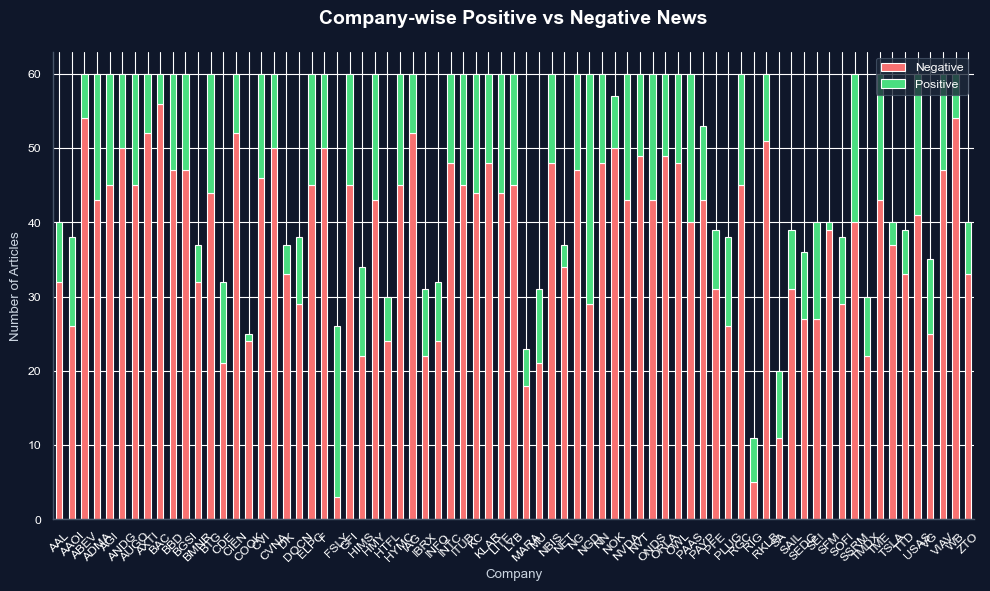

In [31]:
from textblob import TextBlob
import matplotlib.pyplot as plt
import pandas as pd

# Ensure df is correct if running independently
df = pd.read_csv('multi_company_news.csv')

def get_sentiment(text):
    if pd.isna(text):
        return 0
    return TextBlob(str(text)).sentiment.polarity

df['sentiment'] = df['title'].apply(get_sentiment)
df['sentiment_label'] = df['sentiment'].apply(lambda x: 'Positive' if x > 0 else 'Negative')

sentiment_company = df.groupby(['ticker', 'sentiment_label']).size().unstack(fill_value=0)
sentiment_company = sentiment_company.sort_index()

# Extracting columns to safely assign colors depending on if both Positive and Negative exist
colors = []
if 'Negative' in sentiment_company.columns: colors.append('#f87171')
if 'Positive' in sentiment_company.columns: colors.append('#4ade80')

ax = sentiment_company.plot(kind='bar', stacked=True, figsize=(10,6), color=colors)

plt.title('Company-wise Positive vs Negative News', color='white', pad=20, weight='bold', fontsize=14)
plt.xlabel('Company', color='#cbd5e1')
plt.ylabel('Number of Articles', color='#cbd5e1')
plt.xticks(rotation=45, color='white')
plt.yticks(color='white')

fig = plt.gcf()
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#0f172a')
ax.spines['bottom'].set_color('#475569')
ax.spines['left'].set_color('#475569')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(facecolor='#1e293b', edgecolor='#475569', labelcolor='white')

plt.tight_layout()
# Save the PNG explicitly for the dashboard
plt.savefig('static/graphs/sentiment_distribution.png', transparent=True, dpi=300)
print('Saved static/graphs/sentiment_distribution.png')
plt.show()


## HEATMAPS


In [23]:
for ticker in tickers:

    df_t = df_merged[df_merged["Ticker"] == ticker].copy()

    if len(df_t) < 30:
        continue

    df_corr = df_t[[
        'Sentiment_7D','News_Intensity_7D',
        'Return_1D','Volatility_5D',
        'Volume_Spike','Momentum_3D','Return_3D'
    ]]

    df_corr = df_corr.loc[:, df_corr.nunique() > 1]

    if df_corr.shape[1] < 3:
        print(f"{ticker}: skipped (low variance)")
        continue

    plt.figure(figsize=(10,8))
    sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f")

    plt.title(f"{ticker} Correlation (Smoothed Signals)")
    plt.tight_layout()

    plt.savefig(f"static/stocks/{ticker}_correlation.png")
    plt.close()

### STEP 7: MODELING

**Description**: Scaling and splitting the structured dataset preserving time-series continuity (`shuffle=False`). Evaluating the model ensemble sequentially across **ALL Combined Stocks** and then iteratively looping across **ALL 15 Targeted Companies** to formulate granular `model_comparison.csv` and `model_comparison_per_stock.csv` metrics.

In [29]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import *

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("stock_data_ohlcv.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Ticker","Date"])

# -----------------------------
# FEATURE ENGINEERING
# -----------------------------

# RETURNS
df["Return_1D"] = df.groupby("Ticker")["Close"].pct_change()

# TARGET
df["Return_3D"] = df.groupby("Ticker")["Close"].pct_change(3).shift(-3)
df["Direction"] = (df["Return_3D"] > 0.002).astype(int)   # threshold removes noise

# VOLATILITY
df["Volatility_5D"] = df.groupby("Ticker")["Return_1D"].transform(lambda x: x.rolling(5).std())
df["Volatility_10D"] = df.groupby("Ticker")["Return_1D"].transform(lambda x: x.rolling(10).std())

# VOLUME
df["Volume_Avg_5D"] = df.groupby("Ticker")["Volume"].transform(lambda x: x.rolling(5).mean())
df["Volume_Spike"] = df["Volume"] / df["Volume_Avg_5D"]
df["Volume_Trend"] = df.groupby("Ticker")["Volume"].pct_change(3)

# MOMENTUM
df["Momentum_3D"] = df.groupby("Ticker")["Close"].pct_change(3)
df["Momentum_5D"] = df.groupby("Ticker")["Close"].pct_change(5)

# TREND
df["Trend_5D"] = df.groupby("Ticker")["Close"].pct_change(5)

# PRICE BEHAVIOR
df["High_Low_Range"] = (df["High"] - df["Low"]) / df["Close"]
df["Close_Open_Change"] = (df["Close"] - df["Open"]) / df["Open"]

# -----------------------------
# 🔥 TECHNICAL INDICATORS (FIXED)
# -----------------------------

# RSI
delta = df.groupby("Ticker")["Close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.groupby(df["Ticker"]).transform(lambda x: x.rolling(14).mean())
avg_loss = loss.groupby(df["Ticker"]).transform(lambda x: x.rolling(14).mean())

rs = avg_gain / avg_loss
df["RSI"] = 100 - (100 / (1 + rs))

# MACD
ema12 = df.groupby("Ticker")["Close"].transform(lambda x: x.ewm(span=12, adjust=False).mean())
ema26 = df.groupby("Ticker")["Close"].transform(lambda x: x.ewm(span=26, adjust=False).mean())
df["MACD"] = ema12 - ema26

# Bollinger Width
ma20 = df.groupby("Ticker")["Close"].transform(lambda x: x.rolling(20).mean())
std20 = df.groupby("Ticker")["Close"].transform(lambda x: x.rolling(20).std())
df["Bollinger_Width"] = (std20 * 2) / ma20

# -----------------------------
# LAG FEATURES (CRITICAL)
# -----------------------------
lag_cols = [
    "Return_1D","Volatility_5D","Volatility_10D",
    "Volume_Spike","Volume_Trend",
    "Momentum_3D","Momentum_5D",
    "Trend_5D","High_Low_Range","Close_Open_Change",
    "RSI","MACD","Bollinger_Width"
]

for col in lag_cols:
    df[col+"_lag"] = df.groupby("Ticker")[col].shift(1)

df = df.dropna()

features = [col+"_lag" for col in lag_cols]

# -----------------------------
# MODELING
# -----------------------------
all_results = []

for ticker in df["Ticker"].unique():

    df_t = df[df["Ticker"] == ticker]

    if len(df_t) < 150:
        continue

    X = df_t[features]
    y_reg = df_t["Return_3D"]
    y_clf = df_t["Direction"]

    if y_clf.nunique() < 2:
        continue

    split = int(len(df_t) * 0.8)

    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_reg_train, y_reg_test = y_reg.iloc[:split], y_reg.iloc[split:]
    y_clf_train, y_clf_test = y_clf.iloc[:split], y_clf.iloc[split:]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # -----------------------------
    # REGRESSION
    # -----------------------------
    for name, model in {
        "Linear Regression": LinearRegression(),
        "Ridge": Ridge(alpha=3.0)
    }.items():

        model.fit(X_train_scaled, y_reg_train)
        preds = model.predict(X_test_scaled)

        all_results.append({
            "Ticker": ticker,
            "Model": name,
            "Type": "Regression",
            "RMSE": round(np.sqrt(mean_squared_error(y_reg_test, preds)),4),
            "MAE": round(mean_absolute_error(y_reg_test, preds),4),
            "R2": round(r2_score(y_reg_test, preds),4)
        })

    # -----------------------------
    # CLASSIFICATION
    # -----------------------------
    clf_models = {
        "Decision Tree": DecisionTreeClassifier(max_depth=4, min_samples_leaf=30, random_state=42),
        "Random Forest": RandomForestClassifier(
            n_estimators=150,
            max_depth=5,
            min_samples_leaf=25,
            random_state=42
        ),
        "SVM": SVC(C=0.7, kernel='rbf', probability=True),
        "Naive Bayes": GaussianNB()
    }

    for name, model in clf_models.items():

        if name == "SVM":
            model.fit(X_train_scaled, y_clf_train)
            preds = model.predict(X_test_scaled)
            probs = model.predict_proba(X_test_scaled)[:,1]
        else:
            model.fit(X_train, y_clf_train)
            preds = model.predict(X_test)
            probs = model.predict_proba(X_test)[:,1]

        all_results.append({
            "Ticker": ticker,
            "Model": name,
            "Type": "Classification",
            "Accuracy": round(accuracy_score(y_clf_test, preds),4),
            "Precision": round(precision_score(y_clf_test, preds, zero_division=0),4),
            "Recall": round(recall_score(y_clf_test, preds, zero_division=0),4),
            "F1": round(f1_score(y_clf_test, preds, zero_division=0),4),
            "ROC_AUC": round(roc_auc_score(y_clf_test, probs),4)
        })

# -----------------------------
# SAVE
# -----------------------------
results_df = pd.DataFrame(all_results)

print("\n=== FINAL STABLE RESULTS ===\n")
print(results_df)

results_df.to_csv("stock_model_results.csv", index=False)


=== FINAL STABLE RESULTS ===

   Ticker              Model            Type    RMSE     MAE      R2  \
0    AAPL  Linear Regression      Regression  0.0250  0.0191  0.0056   
1    AAPL              Ridge      Regression  0.0250  0.0191  0.0062   
2    AAPL      Decision Tree  Classification     NaN     NaN     NaN   
3    AAPL      Random Forest  Classification     NaN     NaN     NaN   
4    AAPL                SVM  Classification     NaN     NaN     NaN   
..    ...                ...             ...     ...     ...     ...   
85    XOM              Ridge      Regression  0.0288  0.0238 -0.3511   
86    XOM      Decision Tree  Classification     NaN     NaN     NaN   
87    XOM      Random Forest  Classification     NaN     NaN     NaN   
88    XOM                SVM  Classification     NaN     NaN     NaN   
89    XOM        Naive Bayes  Classification     NaN     NaN     NaN   

    Accuracy  Precision  Recall      F1  ROC_AUC  
0        NaN        NaN     NaN     NaN      NaN  
1 

### STEP 8: CLUSTERING & STEP 9: ASSOCIATION RULE MINING


In [25]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("stock_data_ohlcv.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Ticker", "Date"])

# -----------------------------
# FEATURE ENGINEERING
# -----------------------------
df["Return_1D"] = df.groupby("Ticker")["Close"].pct_change()
df["Return_3D"] = df.groupby("Ticker")["Close"].pct_change(3)

df["Volatility_5D"] = df.groupby("Ticker")["Return_1D"].rolling(5).std().reset_index(0, drop=True)
df["Volatility_10D"] = df.groupby("Ticker")["Return_1D"].rolling(10).std().reset_index(0, drop=True)

df["Volume_Avg_5D"] = df.groupby("Ticker")["Volume"].rolling(5).mean().reset_index(0, drop=True)
df["Volume_Spike"] = df["Volume"] / df["Volume_Avg_5D"]

df["Momentum_3D"] = df.groupby("Ticker")["Close"].diff(3)
df["Momentum_5D"] = df.groupby("Ticker")["Close"].diff(5)

df["Trend_5D"] = df.groupby("Ticker")["Close"].pct_change(5)

df["High_Low_Range"] = (df["High"] - df["Low"]) / df["Close"]
df["Close_Open_Change"] = (df["Close"] - df["Open"]) / df["Open"]

df["Volume_Trend"] = df.groupby("Ticker")["Volume"].pct_change(3)

# Drop NA
df = df.dropna()

# -----------------------------
# CLUSTER FEATURES
# -----------------------------
cluster_features = [
    "Return_1D",
    "Volatility_5D",
    "Volatility_10D",
    "Volume_Spike",
    "Volume_Trend",
    "Momentum_3D",
    "Momentum_5D",
    "Trend_5D",
    "High_Low_Range",
    "Close_Open_Change"
]

# -----------------------------
# PER STOCK CLUSTERING
# -----------------------------
df["Cluster"] = np.nan
df["Cluster_Label"] = None

for ticker in df["Ticker"].unique():

    df_t = df[df["Ticker"] == ticker].copy()

    if len(df_t) < 50:
        continue

    scaler = StandardScaler()
    X = scaler.fit_transform(df_t[cluster_features])

    kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X)

    df.loc[df_t.index, "Cluster"] = clusters

# -----------------------------
# ADVANCED LABELING (DAILY)
# -----------------------------
def assign_label(row):

    if row["Volatility_10D"] > df["Volatility_10D"].quantile(0.75):
        return "Volatile Bull" if row["Return_1D"] > 0 else "Volatile Bear"

    elif row["Trend_5D"] > 0.02:
        return "Strong Uptrend"

    elif row["Trend_5D"] < -0.02:
        return "Strong Downtrend"

    elif row["Volume_Spike"] > 1.3:
        return "Breakout Activity"

    elif abs(row["Return_1D"]) < 0.005:
        return "Sideways"

    elif row["Momentum_3D"] > 0:
        return "Mild Bullish"

    elif row["Momentum_3D"] < 0:
        return "Mild Bearish"

    else:
        return "Neutral"

df["Cluster_Label"] = df.apply(assign_label, axis=1)

# -----------------------------
# SAVE DAILY OUTPUT
# -----------------------------
df.to_csv("clustering_output.csv", index=False)

# -----------------------------
# CLUSTER SUMMARY (OPTIONAL)
# -----------------------------
summary = df.groupby(["Ticker", "Cluster_Label"])[cluster_features].mean()
summary.to_csv("cluster_summary_by_stock.csv")

# =========================================================
# 🔥 NEW: STOCK-LEVEL AGGREGATION (FINAL RESULT)
# =========================================================

# -----------------------------
# AGGREGATE FEATURES
# -----------------------------
stock_summary = df.groupby("Ticker").agg({
    "Return_1D": "mean",
    "Return_3D": "mean",
    "Volatility_5D": "mean",
    "Volatility_10D": "mean",
    "Volume_Spike": "mean",
    "Volume_Trend": "mean",
    "Momentum_3D": "mean",
    "Momentum_5D": "mean",
    "Trend_5D": "mean",
    "High_Low_Range": "mean",
    "Close_Open_Change": "mean"
}).reset_index()

# -----------------------------
# DOMINANT REGIME
# -----------------------------
dominant_cluster = (
    df.groupby(["Ticker", "Cluster_Label"])
    .size()
    .reset_index(name="Count")
)

dominant_cluster = dominant_cluster.sort_values(
    ["Ticker", "Count"], ascending=[True, False]
).drop_duplicates("Ticker")

stock_summary = stock_summary.merge(
    dominant_cluster[["Ticker", "Cluster_Label"]],
    on="Ticker",
    how="left"
)

stock_summary.rename(columns={"Cluster_Label": "Dominant_Regime"}, inplace=True)

# -----------------------------
# FINAL LABEL
# -----------------------------
def final_stock_label(row):

    if row["Volatility_10D"] > df["Volatility_10D"].quantile(0.75):
        return "High Risk - Bullish" if row["Trend_5D"] > 0 else "High Risk - Bearish"

    elif row["Trend_5D"] > 0.02:
        return "Strong Growth Stock"

    elif row["Trend_5D"] < -0.02:
        return "Declining Stock"

    elif row["Volume_Spike"] > 1.2:
        return "High Attention Stock"

    elif abs(row["Return_1D"]) < 0.003:
        return "Stable / Low Movement"

    elif row["Momentum_3D"] > 0:
        return "Moderate Bullish"

    elif row["Momentum_3D"] < 0:
        return "Moderate Bearish"

    else:
        return "Neutral"

stock_summary["Final_Label"] = stock_summary.apply(final_stock_label, axis=1)

# -----------------------------
# SCORE (OPTIONAL BUT IMPRESSIVE)
# -----------------------------
stock_summary["Score"] = (
    (stock_summary["Trend_5D"] * 50) +
    (stock_summary["Momentum_3D"] * 2) -
    (stock_summary["Volatility_10D"] * 30)
).round(2)

# -----------------------------
# FINAL OUTPUT
# -----------------------------
final_output = stock_summary[[
    "Ticker",
    "Final_Label",
    "Dominant_Regime",
    "Score",
    "Return_1D",
    "Trend_5D",
    "Volatility_10D",
    "Volume_Spike"
]]

final_output.to_csv("final_stock_summary.csv", index=False)

print("\n=== FINAL STOCK SUMMARY ===\n")
print(final_output)


=== FINAL STOCK SUMMARY ===

   Ticker            Final_Label   Dominant_Regime  Score  Return_1D  \
0    AAPL  Stable / Low Movement    Strong Uptrend   0.84   0.001002   
1     AMD    High Risk - Bullish     Volatile Bull   1.30   0.002329   
2    AMZN  Stable / Low Movement    Strong Uptrend   0.93   0.001393   
3     BAC  Stable / Low Movement    Strong Uptrend  -0.09   0.000744   
4    CSCO  Stable / Low Movement    Strong Uptrend   0.19   0.000957   
5   GOOGL  Stable / Low Movement    Strong Uptrend   1.72   0.001791   
6    INTC    High Risk - Bullish     Volatile Bull  -0.24   0.001646   
7      KO  Stable / Low Movement          Sideways  -0.02   0.000422   
8    META  Stable / Low Movement    Strong Uptrend   3.83   0.002230   
9    MSFT  Stable / Low Movement    Strong Uptrend   1.19   0.000817   
10   NFLX  Stable / Low Movement    Strong Uptrend   0.24   0.001513   
11    NKE  Stable / Low Movement  Strong Downtrend  -1.36  -0.000962   
12   NVDA    High Risk - Bullish  

In [24]:
final_rules_all = []

for ticker in df_merged["Ticker"].unique():

    df_t = df_merged[df_merged["Ticker"] == ticker].copy()

    if len(df_t) < 30:
        continue

    df_rules = pd.DataFrame()

    df_rules['Sentiment'] = pd.cut(
        df_t['Sentiment_Avg'],
        bins=[-1, -0.1, 0.1, 1],
        labels=['Negative', 'Neutral', 'Positive']
    )

    df_rules['Volume'] = pd.cut(
        df_t['Volume_Spike'],
        bins=[0, 0.8, 1.2, 10],
        labels=['Low', 'Normal', 'High']
    )

    df_rules['Volatility'] = pd.cut(
        df_t['Volatility_5D'],
        bins=[0, df_t['Volatility_5D'].median(), df_t['Volatility_5D'].max()],
        labels=['Low_Vol', 'High_Vol']
    )

    df_rules['Return'] = df_t['Direction'].map({1: 'UP', 0: 'DOWN'})

    df_rules = df_rules.dropna()

    rules_encoded = pd.get_dummies(df_rules)

    frequent_items = apriori(
        rules_encoded.astype(bool),
        min_support=0.02,
        use_colnames=True
    )

    if frequent_items.empty:
        continue

    rules = association_rules(
        frequent_items,
        metric="confidence",
        min_threshold=0.4
    )

    if rules.empty:
        continue

    rules = rules[['antecedents','consequents','support','confidence','lift']]
    rules = rules[rules['lift'] > 1.0]

    if rules.empty:
        continue

    rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
    rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

    rules["Ticker"] = ticker

    final_rules_all.append(rules)

# SAFE CONCAT
if len(final_rules_all) > 0:
    final_rules_df = pd.concat(final_rules_all, ignore_index=True)
else:
    final_rules_df = pd.DataFrame()
    print("⚠️ No rules generated — try lowering thresholds further.")

final_rules_df.to_csv("association_rules_per_stock.csv", index=False)

In [6]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules

# -----------------------------
# LOAD + FEATURES (same as before)
# -----------------------------
df = pd.read_csv("stock_data_ohlcv.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Ticker","Date"])

df["Return_1D"] = df.groupby("Ticker")["Close"].pct_change()
df["Volatility_5D"] = df.groupby("Ticker")["Return_1D"].rolling(5).std().reset_index(0,drop=True)
df["Volume_Avg_5D"] = df.groupby("Ticker")["Volume"].rolling(5).mean().reset_index(0,drop=True)
df["Volume_Spike"] = df["Volume"] / df["Volume_Avg_5D"]
df["Momentum_3D"] = df.groupby("Ticker")["Close"].diff(3)

df = df.dropna()

# -----------------------------
# WEEKLY AGGREGATION
# -----------------------------
df["Week"] = df["Date"].dt.to_period("W")

df_weekly = df.groupby(["Ticker","Week"]).agg({
    "Volatility_5D": "mean",
    "Volume_Spike": "mean",
    "Momentum_3D": "mean",
    "Return_1D": "mean"
}).reset_index()

# -----------------------------
# SMART BINNING
# -----------------------------
def smart_bin(series, name):
    return pd.qcut(series, q=3, labels=[f"{name}_Low", f"{name}_Mid", f"{name}_High"])

df_weekly["Volatility"] = smart_bin(df_weekly["Volatility_5D"], "Vol")
df_weekly["Volume"] = smart_bin(df_weekly["Volume_Spike"], "Volm")
df_weekly["Momentum"] = smart_bin(df_weekly["Momentum_3D"], "Mom")
df_weekly["Return"] = df_weekly["Return_1D"].apply(lambda x: "UP" if x > 0 else "DOWN")

# -----------------------------
# RULE MINING + FILTERING
# -----------------------------
final_rules = []

for ticker in df_weekly["Ticker"].unique():

    df_t = df_weekly[df_weekly["Ticker"] == ticker]

    if len(df_t) < 20:
        continue

    df_rules = df_t[["Volatility","Volume","Momentum","Return"]].dropna()
    encoded = pd.get_dummies(df_rules)

    frequent_items = apriori(encoded.astype(bool), min_support=0.08, use_colnames=True)
    if frequent_items.empty:
        continue

    rules = association_rules(frequent_items, metric="confidence", min_threshold=0.6)
    if rules.empty:
        continue

    # -----------------------------
    # FILTER STRONG RULES
    # -----------------------------
    rules = rules[['antecedents','consequents','support','confidence','lift']]

    rules = rules[
        (rules['support'] >= 0.10) &
        (rules['confidence'] >= 0.65) &
        (rules['lift'] >= 1.20)
    ]

    if rules.empty:
        continue

    # Keep only actionable rules (predicting return)
    rules = rules[rules['consequents'].astype(str).str.contains("Return_")]

    if rules.empty:
        continue

    # -----------------------------
    # REMOVE DUPLICATES (A→B vs B→A)
    # -----------------------------
    rules['pair'] = rules.apply(lambda x: tuple(sorted([tuple(x['antecedents']), tuple(x['consequents'])])), axis=1)
    rules = rules.drop_duplicates(subset="pair")

    # -----------------------------
    # SCORE RULES (IMPORTANT)
    # -----------------------------
    rules["score"] = rules["confidence"] * rules["lift"]

    # Top 3 rules per stock
    rules = rules.sort_values(by="score", ascending=False).head(3)

    # Format text
    rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
    rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

    rules["Ticker"] = ticker

    final_rules.append(rules)

# -----------------------------
# FINAL OUTPUT
# -----------------------------
if len(final_rules) > 0:
    final_rules_df = pd.concat(final_rules, ignore_index=True)
else:
    final_rules_df = pd.DataFrame()

final_rules_df.to_csv("final_meaningful_rules_per_stock.csv", index=False)

print("\n=== FINAL RULES (TOP PER STOCK) ===\n")
print(final_rules_df)


=== FINAL RULES (TOP PER STOCK) ===

                                          antecedents  \
0                  Volume_Volm_High, Momentum_Mom_Low   
1                Volatility_Vol_Low, Momentum_Mom_Low   
2                Momentum_Mom_Low, Volatility_Vol_Mid   
3                   Momentum_Mom_Low, Volume_Volm_Mid   
4                  Momentum_Mom_High, Volume_Volm_Mid   
5               Momentum_Mom_Low, Volatility_Vol_High   
6                  Momentum_Mom_High, Volume_Volm_Mid   
7   Volume_Volm_Mid, Momentum_Mom_High, Volatility...   
8                   Volume_Volm_Low, Momentum_Mom_Low   
9                                    Momentum_Mom_Low   
10                 Momentum_Mom_Mid, Volume_Volm_High   
11               Momentum_Mom_Mid, Volatility_Vol_Mid   
12                                   Momentum_Mom_Low   
13                                  Momentum_Mom_High   
14                 Volume_Volm_High, Momentum_Mom_Low   
15               Momentum_Mom_Low, Volatility_Vol_

### STEP 10, 11, 12: OUTPUT FILES AND VISUALS


In [13]:
df_merged.to_csv("final_dataset.csv", index=False)
df_test_out.to_csv("model_predictions.csv", index=False)
df_merged[['Date', 'Ticker', 'Cluster', 'Cluster_Label']].to_csv("clustering_output.csv", index=False)
if not rules.empty:
    rules.to_csv("association_rules.csv", index=False)

for ticker in df_merged['Ticker'].unique():
    td = df_merged[df_merged['Ticker'] == ticker].copy().sort_values('Date')
    if len(td) < 2: continue
    
    plt.figure(figsize=(6,4)); sns.lineplot(x='Date', y='Close', data=td); plt.title(f"{ticker} Price"); plt.xticks(rotation=45); plt.tight_layout(); plt.savefig(f"static/stocks/{ticker}_price.png"); plt.close()
    plt.figure(figsize=(6,4)); sns.lineplot(x='Date', y='Sentiment_Avg', data=td); plt.title(f"{ticker} Sentiment"); plt.xticks(rotation=45); plt.tight_layout(); plt.savefig(f"static/stocks/{ticker}_sentiment.png"); plt.close()
    plt.figure(figsize=(6,4)); sns.lineplot(x='Date', y='Volatility_5D', data=td); plt.title(f"{ticker} Volatility"); plt.xticks(rotation=45); plt.tight_layout(); plt.savefig(f"static/stocks/{ticker}_volatility.png"); plt.close()
    
    latest = td.iloc[-1]
    t_rows = df_test_out[df_test_out['Ticker'] == ticker]
    p_3d = t_rows.iloc[-1].get('Pred_Linear_Reg', 0.0) if len(t_rows) > 0 else 0.0
    direction = ("UP" if t_rows.iloc[-1].get('Pred_Random_Forest', 0) == 1 else "DOWN") if len(t_rows) > 0 else "FLAT"
    trend = "Bullish" if latest['Sentiment_Avg'] > 0 else "Bearish"
    
    api_dict = {
      "ticker": ticker,
      "avg_sentiment": float(round(latest['Sentiment_Avg'], 4)),
      "trend": trend,
      "volatility": float(round(latest['Volatility_5D'], 4)),
      "prediction_next_3d": float(round(p_3d, 4)),
      "direction": direction
    }
    with open(f"static/data/{ticker}.json", "w") as f:
        json.dump(api_dict, f, indent=4)

print("Visualizations and JSON API exported!")


Visualizations and JSON API exported!
